### Pengantar Filosofi Desain scikit-learn

Desain perpustakaan scikit-learn berpusat pada prinsip-prinsip inti seperti konsistensi, kesederhanaan, modularitas, dan penggunaan kembali. Antarmuka yang seragam memungkinkan pengguna untuk melatih model dengan fungsi fit, membuat prediksi dengan fungsi predict, dan memanipulasi data dengan fungsi transform. Konsistensi ini memudahkan pengguna untuk beralih antar model dan meningkatkan produktivitas. Selain itu, modularitasnya memungkinkan komponen seperti estimator, transformer, dan pipeline untuk digabungkan dan digunakan kembali dalam berbagai tugas pemodelan, sehingga menghemat waktu pengembangan. Penulisan nama perpustakaan ini selalu menggunakan huruf kecil semua dan diucapkan sebagai "sy-kit", yang merupakan singkatan dari kata sains.

### Memahami Estimator

Estimator adalah objek berorientasi objek dalam Python yang mengimplementasikan algoritma untuk belajar dari data secara konsisten di seluruh ekosistem pustaka ini. Setiap estimator memiliki dua metode utama, yaitu fit untuk melatih model dari data dan predict untuk menghasilkan prediksi pada data baru berdasarkan model yang telah dilatih. Terdapat juga metode pintasan fit_predict yang menggabungkan kedua operasi tersebut menjadi satu pemanggilan API, yang biasanya sangat berguna dalam skenario pembelajaran mesin tanpa pengawasan seperti pengelompokan data di mana tidak ada variabel target yang diprediksi.

In [1]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Example data
X = np.array([[1], [2], [3], [4], [5]])  # Feature matrix
y = np.array([1, 2, 3, 3.5, 5])  # Target values

# Create and fit the model
model = LinearRegression()
model.fit(X, y)

# Predict values for new data
X_new = np.array([[6], [7]])
predictions = model.predict(X_new)
print(predictions)

[5.75 6.7 ]


In [3]:
# Fit_predict is not used in LinearRegression,
# but as an example for clustering:
from sklearn.cluster import KMeans

# Example data
X = np.array([[1], [2], [3], [4], [5]])

# KMeans Clustering example
kmeans = KMeans(n_clusters=2)
labels = kmeans.fit_predict(X)
print(labels)

[0 0 0 1 1]


### Transformer dan Metode transform

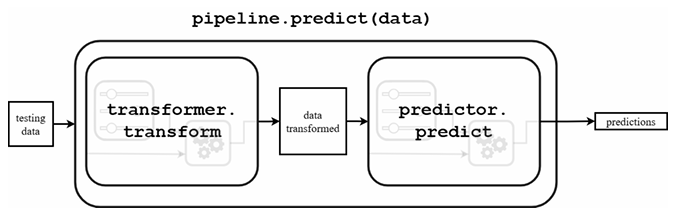

Transformer dalam scikit-learn adalah alat yang memodifikasi data melalui proses seperti penskalaan, normalisasi, atau pengkodean untuk mempersiapkan data sebelum pemodelan. Transformer menggunakan metode fit untuk mempelajari parameter yang diperlukan dari data, dan metode transform untuk menerapkan transformasi tersebut pada data secara konsisten. Untuk alur kerja yang lebih efisien, metode pintasan fit_transform memungkinkan pengguna melakukan kedua langkah pembelajaran parameter dan transformasi secara bersamaan pada data pelatihan. Sangat penting untuk menjaga konsistensi transformasi pada data uji dengan hanya menggunakan metode transform secara terpisah, tanpa melatih ulang metode fit, agar data uji tidak berubah dan prediksi model tetap dapat diandalkan untuk skenario dunia nyata.

In [4]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# Example data
X = np.array([[1, 2], [3, 4], [5, 6]])

# Create a StandardScaler instance
scaler = StandardScaler()

# Fit the scaler on the data
scaler.fit(X)

# Transform the data
X_scaled = scaler.transform(X)
print(X_scaled)

[[-1.22474487 -1.22474487]
 [ 0.          0.        ]
 [ 1.22474487  1.22474487]]


In [5]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# Example data
X = np.array([[1, 2], [3, 4], [5, 6]])

# Create a StandardScaler instance and
# fit_transform the data in one step
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled)

[[-1.22474487 -1.22474487]
 [ 0.          0.        ]
 [ 1.22474487  1.22474487]]


### Menangani Estimator dan Transformer Kustom

API scikit-learn dirancang untuk dapat diperluas, sehingga pengembang dapat membuat estimator dan transformer kustom yang terintegrasi secara mulus ke dalam alur kerja yang ada dengan membuat subkelas dari BaseEstimator dan kelas mixin.

#### Kelas Mixin

Dalam scikit-learn, mixin adalah cara untuk memperluas fungsionalitas kelas tanpa menggunakan pewarisan kelas tradisional, yang sangat berguna untuk berbagi fungsionalitas yang sama antar kelas yang berbeda guna meningkatkan penggunaan kembali kode.

### Pipeline dan Otomatisasi Alur Kerja

Pipeline menyediakan cara terstruktur untuk mengotomatiskan alur kerja pembelajaran mesin dengan merangkai beberapa langkah pemrosesan, seperti prapemrosesan data, pelatihan model, dan prediksi, ke dalam satu objek yang terpadu. Hal ini memastikan bahwa setiap langkah dieksekusi dalam urutan yang benar dan memberikan eksekusi yang konsisten untuk alur kerja yang kompleks.

#### Praktik MLOps

MLOps merujuk pada praktik pengintegrasian alur kerja pembelajaran mesin ke dalam siklus hidup pengembangan perangkat lunak yang lebih besar. Praktik ini berfokus pada otomatisasi proses pengembangan, pengujian, penerapan, dan pemeliharaan model untuk memastikan model tersebut dapat diskalakan dan diandalkan di lingkungan produksi . scikit-learn mendukung alur kerja MLOps melalui alat-alat seperti kelas Pipeline untuk otomatisasi langkah-langkah, GridSearchCV untuk optimasi, serta pustaka penyimpanan model yang kompatibel dengan platform MLOps yang lebih besar seperti MLflow atau Kubeflow.

### Atribut dan Metode Umum

Model-model dalam scikit-learn berbagi beberapa atribut dan metode utama yang memberikan wawasan berharga tentang bagaimana sebuah model belajar dari data yang kompleks. Sebagai contoh, atribut seperti coef_ dan intercept_ pada model linier menyimpan nilai koefisien dan intersep yang telah dipelajari untuk membantu menafsirkan perilaku model. Sementara itu, metode seperti score memungkinkan pengguna untuk mengevaluasi kinerja model dengan mengembalikan metrik standar secara cepat, seperti akurasi untuk model klasifikasi atau R-squared untuk model regresi.

In [6]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Example data
X = np.array([[1], [2], [3], [4], [5]])  # Feature matrix
y = np.array([1, 2, 3, 3.5, 5])  # Target values

# Create and fit the model
model = LinearRegression()
model.fit(X, y)

# Access coefficients (slope of the linear model)
print("Coefficients:", model.coef_)

# Access y-intercept
print("Intercept:", model.intercept_)

# Use score() method to evaluate the model (R-squared value)
print("Model R-squared:", model.score(X, y))

Coefficients: [0.95]
Intercept: 0.04999999999999938
Model R-squared: 0.9809782608695652


### Penyesuaian Hyperparameter dengan Metode Pencarian

Proses penyesuaian hyperparameter sangat penting untuk mengoptimalkan model kandidat, dan scikit-learn mempermudah proses ini dengan antarmuka yang mudah diimplementasikan lewat metode pencarian bawaan seperti GridSearchCV dan RandomizedSearchCV. Selain itu, pengguna dapat menggunakan metode set_params untuk menyesuaikan hyperparameter model secara terprogram secara manual dan get_params untuk mengambil informasi pengaturan hyperparameter yang sedang digunakan saat ini. Fungsionalitas ini memberikan detail keluaran yang memastikan fleksibilitas tinggi saat bereksperimen dengan berbagai konfigurasi model.

In [7]:
from sklearn.ensemble import RandomForestClassifier

# Create a RandomForestClassifier model
model = RandomForestClassifier()

# Set hyperparameters prior to training using set_params()
model.set_params(n_estimators=100, max_depth=10, random_state=42)

# Check the updated parameters
print(model.get_params())

{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


### Bekerja dengan Metadata

Perpustakaan ini menggunakan metadata, seperti tag estimator, untuk mengontrol bagaimana model berperilaku dalam berbagai konteks, termasuk dalam memproses kapabilitas model saat validasi silang dan alur pipeline. Tag ini juga memfasilitasi scikit-learn untuk mengoptimalkan alur kerja secara dinamis dengan mengidentifikasi apakah estimator mampu menangani nilai yang hilang atau data dengan keluaran ganda.

#### Perutean Metadata

Konvensi Umum dan Elemen API dari scikit-learnPengantar Filosofi Desain scikit-learnDesain perpustakaan scikit-learn berpusat pada prinsip-prinsip inti seperti konsistensi, kesederhanaan, modularitas, dan penggunaan kembali. Antarmuka yang seragam memungkinkan pengguna untuk melatih model dengan fungsi fit, membuat prediksi dengan fungsi predict, dan memanipulasi data dengan fungsi transform. Konsistensi ini memudahkan pengguna untuk beralih antar model dan meningkatkan produktivitas. Selain itu, modularitasnya memungkinkan komponen seperti estimator, transformer, dan pipeline untuk digabungkan dan digunakan kembali dalam berbagai tugas pemodelan, sehingga menghemat waktu pengembangan. Penulisan nama perpustakaan ini selalu menggunakan huruf kecil semua dan diucapkan sebagai "sy-kit", yang merupakan singkatan dari kata sains.  Memahami EstimatorEstimator adalah objek berorientasi objek dalam Python yang mengimplementasikan algoritma untuk belajar dari data secara konsisten di seluruh ekosistem pustaka ini. Setiap estimator memiliki dua metode utama, yaitu fit untuk melatih model dari data dan predict untuk menghasilkan prediksi pada data baru berdasarkan model yang telah dilatih. Terdapat juga metode pintasan fit_predict yang menggabungkan kedua operasi tersebut menjadi satu pemanggilan API, yang biasanya sangat berguna dalam skenario pembelajaran mesin tanpa pengawasan seperti pengelompokan data di mana tidak ada variabel target yang diprediksi.  Transformer dan Metode transformTransformer dalam scikit-learn adalah alat yang memodifikasi data melalui proses seperti penskalaan, normalisasi, atau pengkodean untuk mempersiapkan data sebelum pemodelan. Transformer menggunakan metode fit untuk mempelajari parameter yang diperlukan dari data, dan metode transform untuk menerapkan transformasi tersebut pada data secara konsisten. Untuk alur kerja yang lebih efisien, metode pintasan fit_transform memungkinkan pengguna melakukan kedua langkah pembelajaran parameter dan transformasi secara bersamaan pada data pelatihan. Sangat penting untuk menjaga konsistensi transformasi pada data uji dengan hanya menggunakan metode transform secara terpisah, tanpa melatih ulang metode fit, agar data uji tidak berubah dan prediksi model tetap dapat diandalkan untuk skenario dunia nyata.  Menangani Estimator dan Transformer KustomAPI scikit-learn dirancang untuk dapat diperluas, sehingga pengembang dapat membuat estimator dan transformer kustom yang terintegrasi secara mulus ke dalam alur kerja yang ada dengan membuat subkelas dari BaseEstimator dan kelas mixin.  Kelas MixinDalam scikit-learn, mixin adalah cara untuk memperluas fungsionalitas kelas tanpa menggunakan pewarisan kelas tradisional, yang sangat berguna untuk berbagi fungsionalitas yang sama antar kelas yang berbeda guna meningkatkan penggunaan kembali kode.  Pipeline dan Otomatisasi Alur KerjaPipeline menyediakan cara terstruktur untuk mengotomatiskan alur kerja pembelajaran mesin dengan merangkai beberapa langkah pemrosesan, seperti prapemrosesan data, pelatihan model, dan prediksi, ke dalam satu objek yang terpadu. Hal ini memastikan bahwa setiap langkah dieksekusi dalam urutan yang benar dan memberikan eksekusi yang konsisten untuk alur kerja yang kompleks.  Praktik MLOpsMLOps merujuk pada praktik pengintegrasian alur kerja pembelajaran mesin ke dalam siklus hidup pengembangan perangkat lunak yang lebih besar. Praktik ini berfokus pada otomatisasi proses pengembangan, pengujian, penerapan, dan pemeliharaan model untuk memastikan model tersebut dapat diskalakan dan diandalkan di lingkungan produksi . scikit-learn mendukung alur kerja MLOps melalui alat-alat seperti kelas Pipeline untuk otomatisasi langkah-langkah, GridSearchCV untuk optimasi, serta pustaka penyimpanan model yang kompatibel dengan platform MLOps yang lebih besar seperti MLflow atau Kubeflow.  Atribut dan Metode UmumModel-model dalam scikit-learn berbagi beberapa atribut dan metode utama yang memberikan wawasan berharga tentang bagaimana sebuah model belajar dari data yang kompleks. Sebagai contoh, atribut seperti coef_ dan intercept_ pada model linier menyimpan nilai koefisien dan intersep yang telah dipelajari untuk membantu menafsirkan perilaku model. Sementara itu, metode seperti score memungkinkan pengguna untuk mengevaluasi kinerja model dengan mengembalikan metrik standar secara cepat, seperti akurasi untuk model klasifikasi atau R-squared untuk model regresi.  Penyesuaian Hyperparameter dengan Metode PencarianProses penyesuaian hyperparameter sangat penting untuk mengoptimalkan model kandidat, dan scikit-learn mempermudah proses ini dengan antarmuka yang mudah diimplementasikan lewat metode pencarian bawaan seperti GridSearchCV dan RandomizedSearchCV. Selain itu, pengguna dapat menggunakan metode set_params untuk menyesuaikan hyperparameter model secara terprogram secara manual dan get_params untuk mengambil informasi pengaturan hyperparameter yang sedang digunakan saat ini. Fungsionalitas ini memberikan detail keluaran yang memastikan fleksibilitas tinggi saat bereksperimen dengan berbagai konfigurasi model.  Bekerja dengan MetadataPerpustakaan ini menggunakan metadata, seperti tag estimator, untuk mengontrol bagaimana model berperilaku dalam berbagai konteks, termasuk dalam memproses kapabilitas model saat validasi silang dan alur pipeline. Tag ini juga memfasilitasi scikit-learn untuk mengoptimalkan alur kerja secara dinamis dengan mengidentifikasi apakah estimator mampu menangani nilai yang hilang atau data dengan keluaran ganda.  Perutean MetadataPerutean metadata adalah fitur yang memungkinkan pengguna untuk mengontrol secara dinamis bagaimana informasi tambahan, seperti bobot sampel atau label grup, diteruskan antara objek perute dan konsumen dalam alur kerja. Hal ini membuat alur kerja menjadi lebih fleksibel karena metadata dapat diarahkan hanya pada langkah-langkah pemrosesan yang memerlukan informasi tersebut, sehingga mengurangi perlunya intervensi manual dan memastikan pelatihan model yang lebih akurat.

### Praktik Terbaik Penggunaan API

Penerapan praktik terbaik memastikan bahwa kode yang dibangun dari antarmuka scikit-learn tetap jelas, modular, dan mudah dikelola untuk mempermudah perbaikan kesalahan. Beberapa praktik utama yang disarankan meliputi penggunaan antarmuka API yang seragam untuk semua estimator, penerapan prapemrosesan data yang selalu konsisten sebelum disalurkan ke model, dan penggunaan Pipeline untuk menyederhanakan kode pada operasi yang kompleks. Praktik penting lainnya mencakup evaluasi kinerja model dengan teknik validasi silang untuk memastikan kemampuan generalisasi yang andal, serta pencarian nilai optimal model menggunakan alat tuning hyperparameter yang tersedia.